In [20]:
# Step 1: Download the dataset

In [10]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [11]:
# Step 3: Load the NIFTY 50 minute data
# Note: The dataset contains multiple files, we'll use the 1-minute data

file_path = "/content/drive/MyDrive/WiDS 2025/Week 0/NIFTY 50_minute.csv"
nifty_data = pd.read_csv(file_path)

# Display basic information
print("Dataset shape:", nifty_data.shape)
print("\nFirst few rows:")
print(nifty_data.head())
print("\nColumn names:", nifty_data.columns.tolist())
print("\nData types:")
print(nifty_data.dtypes)

Dataset shape: (975321, 6)

First few rows:
                  date     open     high      low    close  volume
0  2015-01-09 09:15:00  8285.45  8295.90  8285.45  8292.10       0
1  2015-01-09 09:16:00  8292.60  8293.60  8287.20  8288.15       0
2  2015-01-09 09:17:00  8287.40  8293.90  8287.40  8293.90       0
3  2015-01-09 09:18:00  8294.25  8300.65  8293.90  8300.65       0
4  2015-01-09 09:19:00  8300.60  8301.30  8298.75  8301.20       0

Column names: ['date', 'open', 'high', 'low', 'close', 'volume']

Data types:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [12]:
# Step 4: Data preprocessing
# Convert date column to datetime (assuming column name is 'date' or similar)
# Adjust column name based on actual data
# Common column names might be: 'datetime', 'date', 'time', etc.

# Check column names first
print("Available columns:", nifty_data.columns.tolist())

# Find the datetime column (you may need to adjust this)
date_col = [col for col in nifty_data.columns if 'date' in col.lower() or 'time' in col.lower()]
if date_col:
    nifty_data[date_col[0]] = pd.to_datetime(nifty_data[date_col[0]])
    nifty_data = nifty_data.set_index(date_col[0])
    print(f"Using '{date_col[0]}' as datetime index")
else:
    # If no obvious date column, check the first few columns
    nifty_data.iloc[:, 0] = pd.to_datetime(nifty_data.iloc[:, 0])
    nifty_data = nifty_data.set_index(nifty_data.columns[0])
    print(f"Using first column '{nifty_data.columns[0]}' as datetime index")

# Sort by date
nifty_data = nifty_data.sort_index()

# Verify the data
print("\nData index info:")
print(f"Date range: {nifty_data.index.min()} to {nifty_data.index.max()}")
print(f"Total periods: {len(nifty_data)}")

# Check for missing values
print("\nMissing values:")
print(nifty_data.isnull().sum())

Available columns: ['date', 'open', 'high', 'low', 'close', 'volume']
Using 'date' as datetime index

Data index info:
Date range: 2015-01-09 09:15:00 to 2025-07-25 15:29:00
Total periods: 975321

Missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [13]:
# Step 5: Calculate returns
# Use closing price for return calculation (adjust column name if needed)
close_col = [col for col in nifty_data.columns if 'close' in col.lower()]
if not close_col:
    close_col = [col for col in nifty_data.columns if 'price' in col.lower() or 'last' in col.lower()]

if close_col:
    close_price = nifty_data[close_col[0]]
    print(f"Using '{close_col[0]}' column for close price")
else:
    # Try to identify the close price column by position (usually the 4th column in OHLC)
    close_price = nifty_data.iloc[:, 3]
    print("Using the 4th column as close price (assuming OHLC format)")

# Calculate percentage returns
returns = close_price.pct_change() * 100
returns = returns.dropna()

print(f"\nReturns statistics:")
print(f"Mean return: {returns.mean():.4f}%")
print(f"Standard deviation: {returns.std():.4f}%")
print(f"Min return: {returns.min():.4f}%")
print(f"Max return: {returns.max():.4f}%")
print(f"Skewness: {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurtosis():.4f}")

# Count returns within different ranges
print(f"\nReturn distribution:")
print(f"Returns > 0: {(returns > 0).sum()} ({((returns > 0).sum()/len(returns)*100):.2f}%)")
print(f"Returns < 0: {(returns < 0).sum()} ({((returns < 0).sum()/len(returns)*100):.2f}%)")
print(f"Returns = 0: {(returns == 0).sum()} ({((returns == 0).sum()/len(returns)*100):.2f}%)")

Using 'close' column for close price

Returns statistics:
Mean return: 0.0001%
Standard deviation: 0.0518%
Min return: -8.6473%
Max return: 6.2220%
Skewness: -12.1992
Kurtosis: 2783.9665

Return distribution:
Returns > 0: 486109 (49.84%)
Returns < 0: 482079 (49.43%)
Returns = 0: 7132 (0.73%)


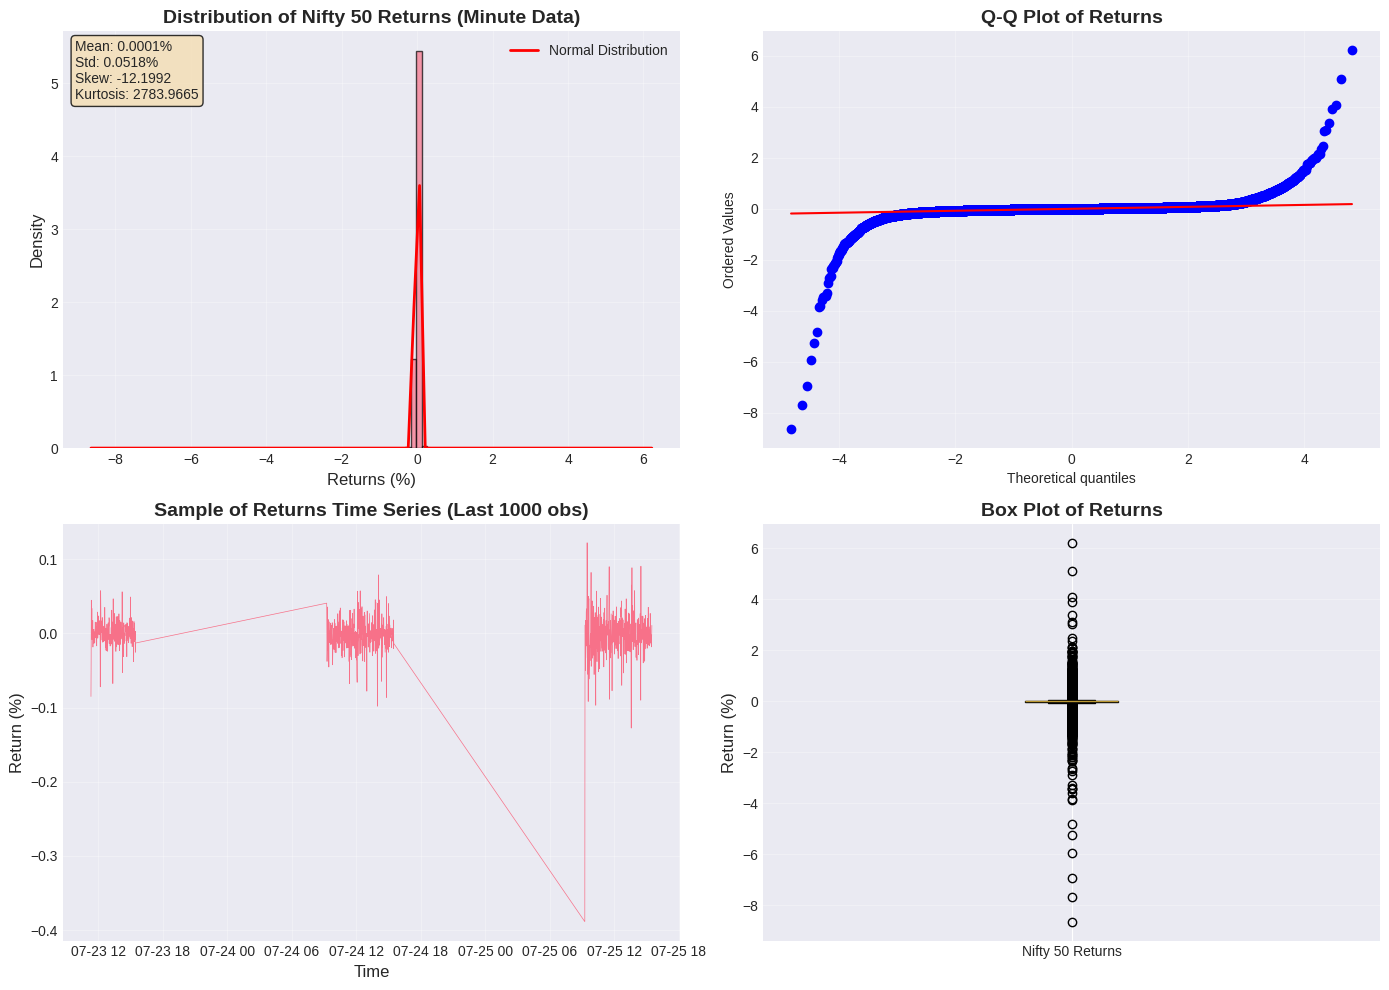

In [14]:
# Step 6: Plot returns histogram
plt.figure(figsize=(14, 10))

# Subplot 1: Returns histogram
plt.subplot(2, 2, 1)
n, bins, patches = plt.hist(returns, bins=100, edgecolor='black', alpha=0.7, density=True)

# Add normal distribution curve for comparison
from scipy.stats import norm
x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, norm.pdf(x, returns.mean(), returns.std()), 'r-', linewidth=2, label='Normal Distribution')

plt.xlabel('Returns (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Nifty 50 Returns (Minute Data)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics box
stats_text = f'Mean: {returns.mean():.4f}%\nStd: {returns.std():.4f}%\nSkew: {returns.skew():.4f}\nKurtosis: {returns.kurtosis():.4f}'
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10)

# Subplot 2: Q-Q plot
plt.subplot(2, 2, 2)
from scipy import stats
stats.probplot(returns, dist="norm", plot=plt)
plt.title('Q-Q Plot of Returns', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 3: Time series of returns (sample of recent data for clarity)
plt.subplot(2, 2, 3)
sample_returns = returns[-1000:]  # Last 1000 observations for clarity
plt.plot(sample_returns.index, sample_returns, linewidth=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.title('Sample of Returns Time Series (Last 1000 obs)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 4: Box plot of returns
plt.subplot(2, 2, 4)
plt.boxplot(returns, vert=True, patch_artist=True)
plt.ylabel('Return (%)', fontsize=12)
plt.title('Box Plot of Returns', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks([1], ['Nifty 50 Returns'])

plt.tight_layout()
plt.show()

In [15]:
# Step 7: Calculate rolling standard deviation (volatility)
# Using pandas.DataFrame.rolling() as requested

# Define window sizes (in minutes)
window_1h = 60  # 1-hour window (60 minutes)
window_1d = 390  # 1-day window (approx 6.5 trading hours = 390 minutes)
window_1w = 1950  # 1-week window (5 days * 390 minutes)

# Calculate rolling standard deviation with different windows
rolling_std_1h = returns.rolling(window=window_1h).std()
rolling_std_1d = returns.rolling(window=window_1d).std()
rolling_std_1w = returns.rolling(window=window_1w).std()

print("Rolling Volatility Statistics:")
print(f"1-hour rolling volatility - Mean: {rolling_std_1h.mean():.4f}%, Max: {rolling_std_1h.max():.4f}%, Min: {rolling_std_1h.min():.4f}%")
print(f"1-day rolling volatility - Mean: {rolling_std_1d.mean():.4f}%, Max: {rolling_std_1d.max():.4f}%, Min: {rolling_std_1d.min():.4f}%")
print(f"1-week rolling volatility - Mean: {rolling_std_1w.mean():.4f}%, Max: {rolling_std_1w.max():.4f}%, Min: {rolling_std_1w.min():.4f}%")

Rolling Volatility Statistics:
1-hour rolling volatility - Mean: 0.0370%, Max: 1.1473%, Min: 0.0000%
1-day rolling volatility - Mean: 0.0419%, Max: 0.6503%, Min: 0.0136%
1-week rolling volatility - Mean: 0.0437%, Max: 0.3763%, Min: 0.0180%


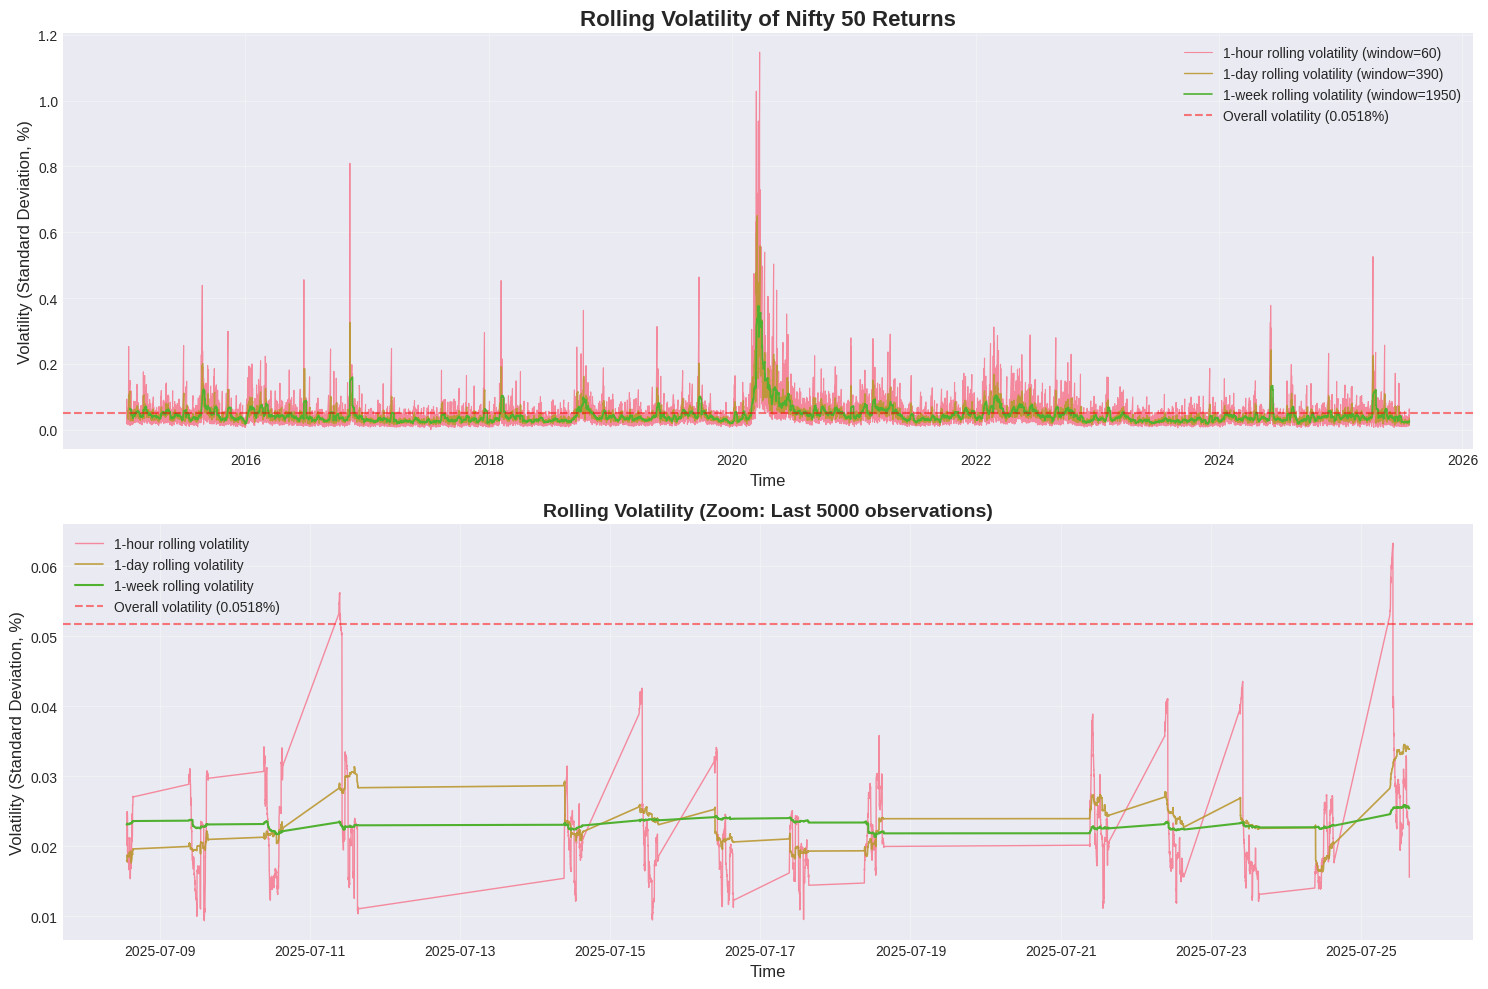

In [16]:
# Step 8: Plot rolling volatility
plt.figure(figsize=(15, 10))

# Subplot 1: Rolling volatility with different windows
plt.subplot(2, 1, 1)
plt.plot(rolling_std_1h.index, rolling_std_1h, label=f'1-hour rolling volatility (window={window_1h})', alpha=0.8, linewidth=0.8)
plt.plot(rolling_std_1d.index, rolling_std_1d, label=f'1-day rolling volatility (window={window_1d})', alpha=0.9, linewidth=1)
plt.plot(rolling_std_1w.index, rolling_std_1w, label=f'1-week rolling volatility (window={window_1w})', alpha=1, linewidth=1.2)

plt.xlabel('Time', fontsize=12)
plt.ylabel('Volatility (Standard Deviation, %)', fontsize=12)
plt.title('Rolling Volatility of Nifty 50 Returns', fontsize=16, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Add horizontal line for average volatility
plt.axhline(y=returns.std(), color='red', linestyle='--', alpha=0.5, label=f'Overall volatility ({returns.std():.4f}%)')
plt.legend(fontsize=10)

# Subplot 2: Zoomed-in view of recent period for clarity
plt.subplot(2, 1, 2)
recent_period = 5000  # Last 5000 observations
if len(rolling_std_1h) > recent_period:
    recent_idx = rolling_std_1h.index[-recent_period:]
    plt.plot(recent_idx, rolling_std_1h[-recent_period:], label=f'1-hour rolling volatility', alpha=0.8, linewidth=1)
    plt.plot(recent_idx, rolling_std_1d[-recent_period:], label=f'1-day rolling volatility', alpha=0.9, linewidth=1.2)
    plt.plot(recent_idx, rolling_std_1w[-recent_period:], label=f'1-week rolling volatility', alpha=1, linewidth=1.5)

    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Volatility (Standard Deviation, %)', fontsize=12)
    plt.title(f'Rolling Volatility (Zoom: Last {recent_period} observations)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Add horizontal line for average volatility
    plt.axhline(y=returns.std(), color='red', linestyle='--', alpha=0.5, label=f'Overall volatility ({returns.std():.4f}%)')
    plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

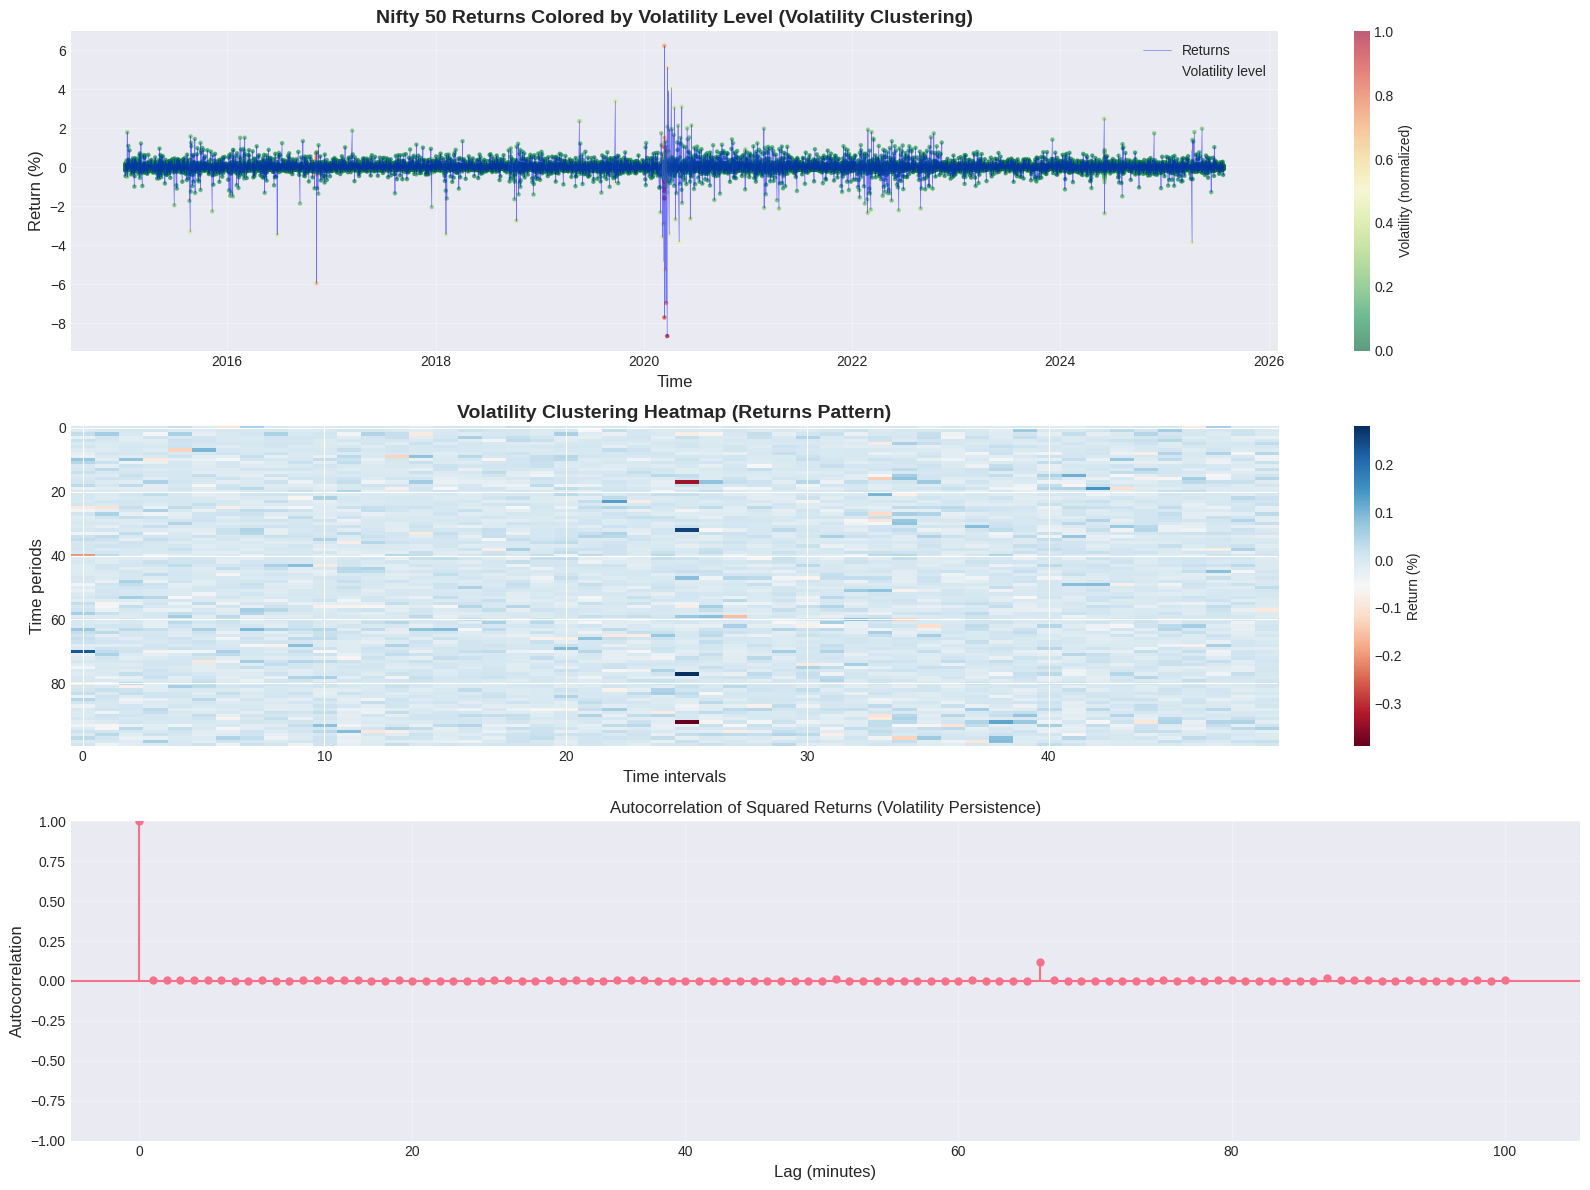

In [17]:
# Step 9: Visualize volatility clustering
plt.figure(figsize=(16, 12))

# Subplot 1: Returns with volatility overlay
plt.subplot(3, 1, 1)
# Plot returns
plt.plot(returns.index, returns, color='blue', alpha=0.5, linewidth=0.5, label='Returns')

# Create a normalized volatility indicator for coloring
vol_norm = (rolling_std_1h - rolling_std_1h.min()) / (rolling_std_1h.max() - rolling_std_1h.min())
# Create scatter plot with color based on volatility
sc = plt.scatter(returns.index, returns, c=vol_norm, cmap='RdYlGn_r', alpha=0.6, s=5, label='Volatility level')
plt.colorbar(sc, label='Volatility (normalized)')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.title('Nifty 50 Returns Colored by Volatility Level (Volatility Clustering)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Subplot 2: Volatility clustering heatmap (recent period)
plt.subplot(3, 1, 2)
# Select a recent period for the heatmap
heatmap_data = returns[-5000:].values.reshape(100, 50)  # Reshape to 100x50 grid

plt.imshow(heatmap_data, aspect='auto', cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Return (%)')
plt.xlabel('Time intervals', fontsize=12)
plt.ylabel('Time periods', fontsize=12)
plt.title('Volatility Clustering Heatmap (Returns Pattern)', fontsize=14, fontweight='bold')

# Subplot 3: Volatility persistence - autocorrelation of squared returns
plt.subplot(3, 1, 3)
from statsmodels.graphics.tsaplots import plot_acf

# Use squared returns as a proxy for volatility
squared_returns = returns ** 2
plot_acf(squared_returns.dropna(), lags=100, alpha=0.05, title='Autocorrelation of Squared Returns (Volatility Persistence)', ax=plt.gca())
plt.xlabel('Lag (minutes)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

VOLATILITY CLUSTERING ANALYSIS

Volatility Regimes (based on 1-hour rolling window):
High volatility threshold: 0.0420%
Low volatility threshold: 0.0203%
High volatility periods: 243815 observations
Low volatility periods: 243815 observations
Medium volatility periods: 487690 observations

Returns during different volatility regimes:
High volatility periods - Mean: 0.0006%, Std: 0.0926%
Low volatility periods - Mean: 0.0000%, Std: 0.0168%

Volatility Clustering Metrics:
Maximum consecutive high volatility periods: 10472 observations
Maximum consecutive low volatility periods: 612 observations
Average high volatility cluster length: 63.0 observations


/tmp/ipython-input-3349980356.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  high_vol_starts = returns.index[high_vol_periods & ~high_vol_periods.shift(1).fillna(False)]
/tmp/ipython-input-3349980356.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  high_vol_ends = returns.index[high_vol_periods & ~high_vol_periods.shift(-1).fillna(False)]
/tmp/ipython-input-3349980356.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. 

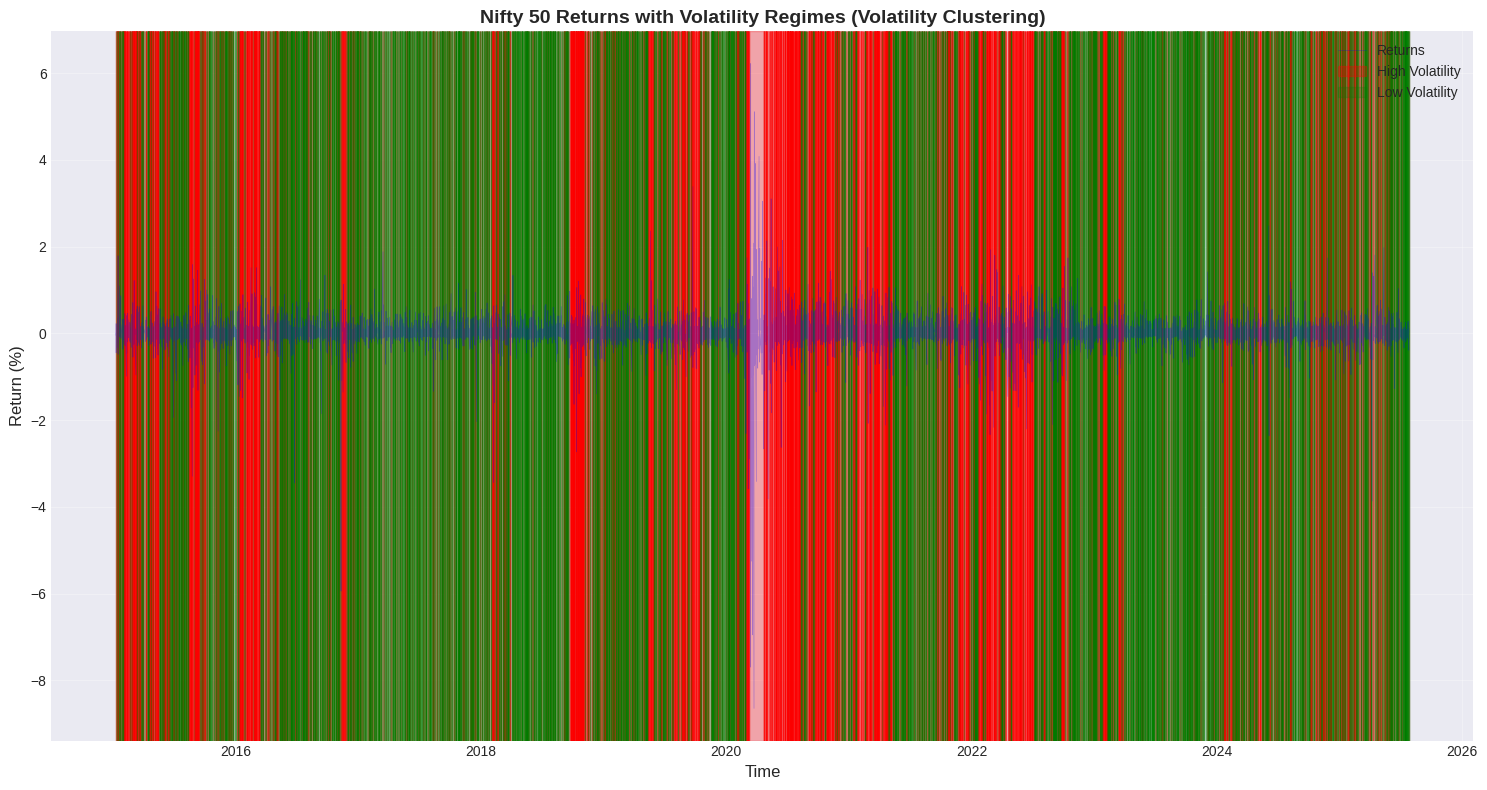

In [18]:
# Step 10: Advanced volatility clustering analysis
print("=" * 80)
print("VOLATILITY CLUSTERING ANALYSIS")
print("=" * 80)

# Calculate volatility regimes
high_vol_threshold = rolling_std_1h.quantile(0.75)  # Top 25% as high volatility
low_vol_threshold = rolling_std_1h.quantile(0.25)   # Bottom 25% as low volatility

high_vol_periods = rolling_std_1h > high_vol_threshold
low_vol_periods = rolling_std_1h < low_vol_threshold

print(f"\nVolatility Regimes (based on 1-hour rolling window):")
print(f"High volatility threshold: {high_vol_threshold:.4f}%")
print(f"Low volatility threshold: {low_vol_threshold:.4f}%")
print(f"High volatility periods: {high_vol_periods.sum()} observations")
print(f"Low volatility periods: {low_vol_periods.sum()} observations")
print(f"Medium volatility periods: {len(rolling_std_1h) - high_vol_periods.sum() - low_vol_periods.sum()} observations")

# Analyze returns during different volatility regimes
returns_high_vol = returns[high_vol_periods]
returns_low_vol = returns[low_vol_periods]

print(f"\nReturns during different volatility regimes:")
print(f"High volatility periods - Mean: {returns_high_vol.mean():.4f}%, Std: {returns_high_vol.std():.4f}%")
print(f"Low volatility periods - Mean: {returns_low_vol.mean():.4f}%, Std: {returns_low_vol.std():.4f}%")

# Calculate volatility clustering metric (persistence)
# Count consecutive periods of high/low volatility
def count_consecutive_periods(series):
    """Count consecutive periods where condition is True"""
    if len(series) == 0:
        return 0

    max_count = 0
    current_count = 0

    for value in series:
        if value:
            current_count += 1
            max_count = max(max_count, current_count)
        else:
            current_count = 0

    return max_count

max_consecutive_high = count_consecutive_periods(high_vol_periods)
max_consecutive_low = count_consecutive_periods(low_vol_periods)

print(f"\nVolatility Clustering Metrics:")
print(f"Maximum consecutive high volatility periods: {max_consecutive_high} observations")
print(f"Maximum consecutive low volatility periods: {max_consecutive_low} observations")
print(f"Average high volatility cluster length: {high_vol_periods.sum() / (high_vol_periods.diff().ne(0).sum() / 2):.1f} observations")

# Plot volatility regimes
plt.figure(figsize=(15, 8))

# Plot returns with volatility regime shading
plt.plot(returns.index, returns, color='blue', alpha=0.3, linewidth=0.5, label='Returns')

# Shade high volatility periods
high_vol_starts = returns.index[high_vol_periods & ~high_vol_periods.shift(1).fillna(False)]
high_vol_ends = returns.index[high_vol_periods & ~high_vol_periods.shift(-1).fillna(False)]

for start, end in zip(high_vol_starts, high_vol_ends):
    plt.axvspan(start, end, alpha=0.3, color='red', label='High Volatility' if start == high_vol_starts[0] else "")

# Shade low volatility periods
low_vol_starts = returns.index[low_vol_periods & ~low_vol_periods.shift(1).fillna(False)]
low_vol_ends = returns.index[low_vol_periods & ~low_vol_periods.shift(-1).fillna(False)]

for start, end in zip(low_vol_starts, low_vol_ends):
    plt.axvspan(start, end, alpha=0.2, color='green', label='Low Volatility' if start == low_vol_starts[0] else "")

plt.xlabel('Time', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.title('Nifty 50 Returns with Volatility Regimes (Volatility Clustering)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Step 11: Summary statistics table
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_data = {
    'Metric': [
        'Total Observations',
        'Mean Return (%)',
        'Standard Deviation (%)',
        'Minimum Return (%)',
        'Maximum Return (%)',
        'Skewness',
        'Kurtosis',
        'Positive Returns (%)',
        'Negative Returns (%)',
        'Zero Returns (%)',
        '1-hour Volatility Mean (%)',
        '1-day Volatility Mean (%)',
        '1-week Volatility Mean (%)'
    ],
    'Value': [
        len(returns),
        f"{returns.mean():.4f}",
        f"{returns.std():.4f}",
        f"{returns.min():.4f}",
        f"{returns.max():.4f}",
        f"{returns.skew():.4f}",
        f"{returns.kurtosis():.4f}",
        f"{((returns > 0).sum()/len(returns)*100):.2f}",
        f"{((returns < 0).sum()/len(returns)*100):.2f}",
        f"{((returns == 0).sum()/len(returns)*100):.2f}",
        f"{rolling_std_1h.mean():.4f}",
        f"{rolling_std_1d.mean():.4f}",
        f"{rolling_std_1w.mean():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

SUMMARY STATISTICS

                    Metric     Value
        Total Observations    975320
           Mean Return (%)    0.0001
    Standard Deviation (%)    0.0518
        Minimum Return (%)   -8.6473
        Maximum Return (%)    6.2220
                  Skewness  -12.1992
                  Kurtosis 2783.9665
      Positive Returns (%)     49.84
      Negative Returns (%)     49.43
          Zero Returns (%)      0.73
1-hour Volatility Mean (%)    0.0370
 1-day Volatility Mean (%)    0.0419
1-week Volatility Mean (%)    0.0437
